# 01 — Exploratory Data Analysis (EDA)

This notebook explores ISIC 2018 and ISIC 2020 in their **binary** form (benign vs malignant).
It produces figures to use in the report and highlights the domain shift.

**Outputs:** saved under `results/figures/eda/`.


In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

root = Path.cwd()
while not (root / 'data').exists() and root != root.parent:
    root = root.parent
os.chdir(root)

FIG_DIR = Path('results/figures/eda')
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style='whitegrid')


## 1. Load processed datasets


In [2]:
df18 = pd.read_csv('data/processed/isic2018/train.csv')
df20 = pd.read_csv('data/processed/isic2020/train.csv')

if 'source' not in df18.columns:
    df18['source'] = 'isic2018'
if 'source' not in df20.columns:
    df20['source'] = 'isic2020'

label_map = {0: 'benign', 1: 'malignant'}
df18['label'] = df18['target'].map(label_map)
df20['label'] = df20['target'].map(label_map)

print('ISIC 2018:', df18.shape)
print('ISIC 2020:', df20.shape)


ISIC 2018: (8012, 5)
ISIC 2020: (26500, 5)


## 2. Class distribution (binary)


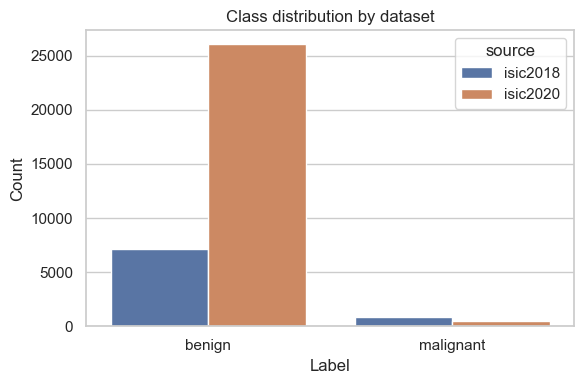

In [3]:
df_all = pd.concat([df18, df20], ignore_index=True)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_all, x='label', hue='source')
ax.set_title('Class distribution by dataset')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'class_distribution.png', dpi=200)
plt.show()


## 3. Image grids (benign vs malignant)


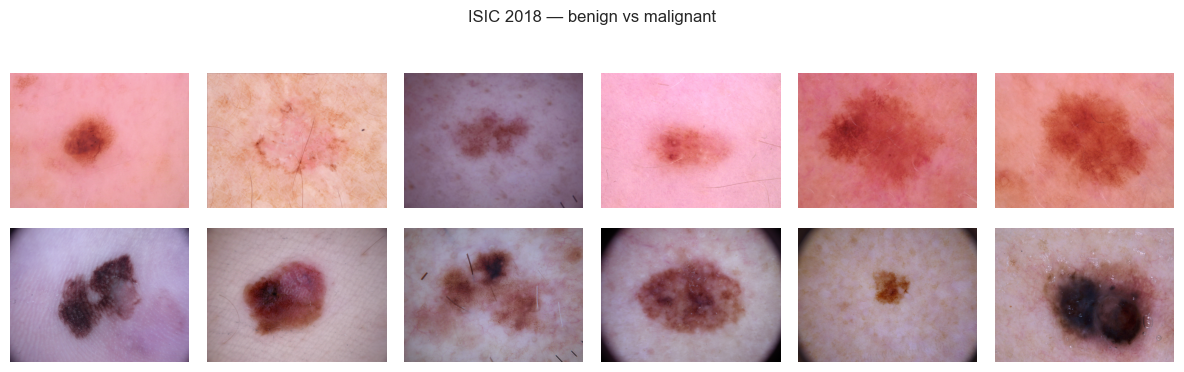

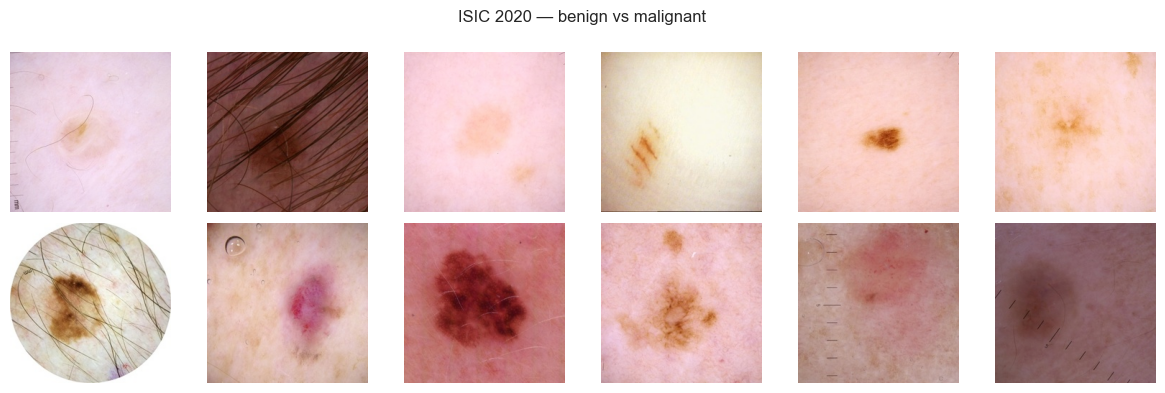

In [4]:
from PIL import Image
import numpy as np

def plot_class_grid(df, title, n_per_class=6):
    classes = ['benign', 'malignant']
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 2, len(classes) * 2))
    axes = np.atleast_2d(axes)

    for i, cls in enumerate(classes):
        subset = df[df['label'] == cls]
        if len(subset) == 0:
            continue
        samples = subset.sample(n=min(n_per_class, len(subset)), random_state=SEED)
        for j, (_, row) in enumerate(samples.iterrows()):
            img = Image.open(row['filepath']).convert('RGB')
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
        for j in range(len(samples), n_per_class):
            axes[i, j].axis('off')
        axes[i, 0].set_ylabel(cls, fontsize=10)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    return fig

fig = plot_class_grid(df18, 'ISIC 2018 — benign vs malignant')
plt.savefig(FIG_DIR / 'grid_isic2018.png', dpi=200)
plt.show()

fig = plot_class_grid(df20, 'ISIC 2020 — benign vs malignant')
plt.savefig(FIG_DIR / 'grid_isic2020.png', dpi=200)
plt.show()


## 4. Basic image statistics (mean / std)


In [5]:
import torch
from torchvision import transforms

to_tensor = transforms.ToTensor()

def compute_mean_std(df, sample_size=500):
    sample = df.sample(n=min(sample_size, len(df)), random_state=SEED)
    sum_ = torch.zeros(3)
    sumsq = torch.zeros(3)
    count = 0

    for path in sample['filepath']:
        img = Image.open(path).convert('RGB')
        t = to_tensor(img)
        sum_ += t.sum(dim=[1, 2])
        sumsq += (t ** 2).sum(dim=[1, 2])
        count += t.shape[1] * t.shape[2]

    mean = sum_ / count
    std = torch.sqrt(sumsq / count - mean ** 2)
    return mean.numpy(), std.numpy()

mean18, std18 = compute_mean_std(df18)
mean20, std20 = compute_mean_std(df20)

stats = pd.DataFrame([
    {'dataset': 'isic2018', 'mean': mean18, 'std': std18},
    {'dataset': 'isic2020', 'mean': mean20, 'std': std20},
])
stats


,dataset,mean,std
0,isic2018,"[0.7539488, 0.54452384, 0.5666978]","[0.14051369, 0.15302545, 0.17122258]"
1,isic2020,"[0.8233714, 0.63184273, 0.5931284]","[0.1502683, 0.18884431, 0.21475579]"


## 5. Feature t-SNE (ResNet18, ImageNet weights)


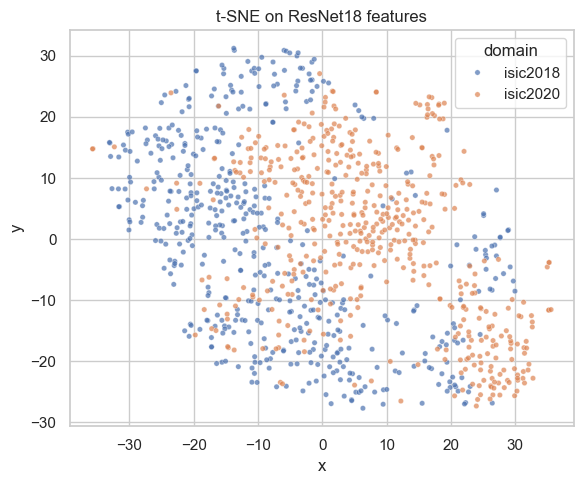

In [6]:
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.manifold import TSNE

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
weights = models.ResNet18_Weights.DEFAULT
transform = weights.transforms()

class ImagePathDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img)

def extract_features(paths, batch_size=64):
    dataset = ImagePathDataset(paths, transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model = models.resnet18(weights=weights)
    model.fc = torch.nn.Identity()
    model.eval().to(device)

    feats = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).cpu().numpy()
            feats.append(out)
    return np.concatenate(feats, axis=0)

N = 500
sample18 = df18.sample(n=min(N, len(df18)), random_state=SEED)
sample20 = df20.sample(n=min(N, len(df20)), random_state=SEED)

feat18 = extract_features(sample18['filepath'].tolist())
feat20 = extract_features(sample20['filepath'].tolist())

features = np.vstack([feat18, feat20])
domains = (['isic2018'] * len(feat18)) + (['isic2020'] * len(feat20))

tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED)
emb = tsne.fit_transform(features)

tsne_df = pd.DataFrame({
    'x': emb[:, 0],
    'y': emb[:, 1],
    'domain': domains
})

plt.figure(figsize=(6, 5))
sns.scatterplot(data=tsne_df, x='x', y='y', hue='domain', s=15, alpha=0.7)
plt.title('t-SNE on ResNet18 features')
plt.tight_layout()
plt.savefig(FIG_DIR / 'tsne_resnet18.png', dpi=200)
plt.show()
